# RescueLink AI - Training & Evaluation Notebook
This notebook trains and evaluates the emergency classification model, visualizes accuracy, and saves artifacts.
This notebook will guide you step by step:
1. Load the dataset
2. Tokenize the text
3. Train the model
4. Evaluate accuracy
5. Visualize results



In [23]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizerFast

from models.emergency_classifier import EmergencyClassifier
from utils.encoders import load_encoders


## Step 0: Load Latest Trained Model

Before training, we check if a saved model file (`models/emergency_model.pt`) exists.  
- If it does, we load the weights into our `EmergencyClassifier` so we can continue training or run inference without starting from scratch.  
- If not, we initialize a fresh model.


In [24]:
MODEL_PATH = "models/emergency_model.pt"

# Recreate the model architecture
model = EmergencyClassifier()

# Load latest trained weights if available
if os.path.exists(MODEL_PATH):
    print("Loading latest trained model...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
else:
    print("No saved model found, starting fresh.")


Loading latest trained model...


## Step 1: Load the Dataset
Run the next cell to load the emergency dataset from `data/emergency_dataset.csv`.
We’ll split it into training and validation sets.


In [25]:
# Load the unified dataset generated by generate_dataset.py
df = pd.read_csv("data/emergency_dataset.csv")

# Split into train and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))


Train size: 4800
Validation size: 1200


## Step 2: Tokenization
Run this cell to convert text into numerical tokens using DistilBERT’s tokenizer.
This prepares the data for the model.


In [26]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(train_df["text"].tolist(), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_df["text"].tolist(), truncation=True, padding=True, max_length=128)


In [27]:
from training.train import EmergencyDataset

train_dataset = EmergencyDataset(train_encodings, train_df["type_label"].tolist(), train_df["severity_label"].tolist())
val_dataset = EmergencyDataset(val_encodings, val_df["type_label"].tolist(), val_df["severity_label"].tolist())

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


## Step 3: Training Loop
Run this cell to train the EmergencyClassifier model.
You’ll see training and validation loss after each epoch.


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmergencyClassifier().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

train_losses, val_losses = [], []

for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask)
        loss_type = torch.nn.functional.cross_entropy(outputs["type_logits"], labels[:,0])
        loss_severity = torch.nn.functional.cross_entropy(outputs["severity_logits"], labels[:,1])
        loss = loss_type + loss_severity

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)
            loss_type = torch.nn.functional.cross_entropy(outputs["type_logits"], labels[:,0])
            loss_severity = torch.nn.functional.cross_entropy(outputs["severity_logits"], labels[:,1])
            val_loss += (loss_type + loss_severity).item()
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 1 | Train Loss: 291.0973 | Val Loss: 17.3206
Epoch 2 | Train Loss: 54.0878 | Val Loss: 14.4285
Epoch 3 | Train Loss: 47.9110 | Val Loss: 14.3136


## Step 4: Accuracy & Metrics
Run this cell to evaluate the model on the validation set.
You’ll see precision, recall, and F1 scores.


In [29]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()
        outputs = model(input_ids, attention_mask)

        preds_type = torch.argmax(outputs["type_logits"], dim=1).cpu().numpy()
        preds_severity = torch.argmax(outputs["severity_logits"], dim=1).cpu().numpy()

        y_true.extend(labels)
        y_pred.extend(list(zip(preds_type, preds_severity)))

print(classification_report([t[0] for t in y_true], [p[0] for p in y_pred]))
print(classification_report([t[1] for t in y_true], [p[1] for p in y_pred]))


              precision    recall  f1-score   support

           0       0.98      0.93      0.96       194
           1       0.85      0.99      0.91       206
           2       0.94      0.97      0.95       201
           3       0.99      0.92      0.96       209
           4       0.98      0.98      0.98       178
           5       0.99      0.93      0.96       212

    accuracy                           0.95      1200
   macro avg       0.96      0.95      0.95      1200
weighted avg       0.96      0.95      0.95      1200

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       312
           1       1.00      0.94      0.97       282
           2       0.99      0.94      0.96       303
           3       1.00      0.97      0.98       303

    accuracy                           0.96      1200
   macro avg       0.97      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



## Step 5: Confusion Matrices & Loss Curves
Run these cells to visualize:
- Where the model misclassifies (confusion matrices)
- How training progressed (loss curves)


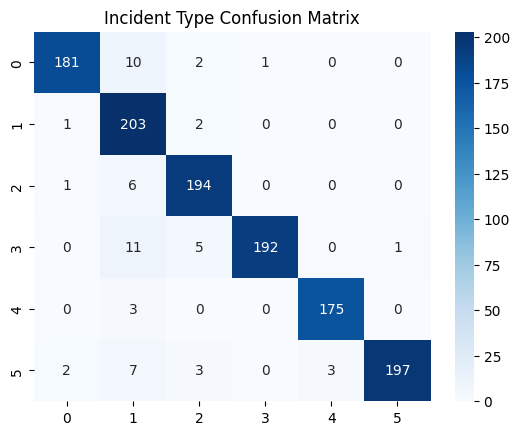

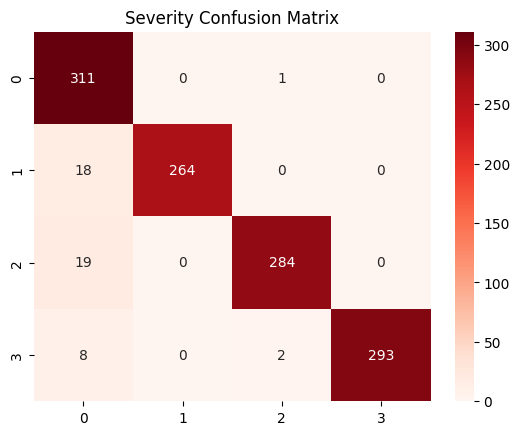

In [30]:
cm_type = confusion_matrix([t[0] for t in y_true], [p[0] for p in y_pred])
sns.heatmap(cm_type, annot=True, fmt="d", cmap="Blues")
plt.title("Incident Type Confusion Matrix")
plt.show()

cm_severity = confusion_matrix([t[1] for t in y_true], [p[1] for p in y_pred])
sns.heatmap(cm_severity, annot=True, fmt="d", cmap="Reds")
plt.title("Severity Confusion Matrix")
plt.show()


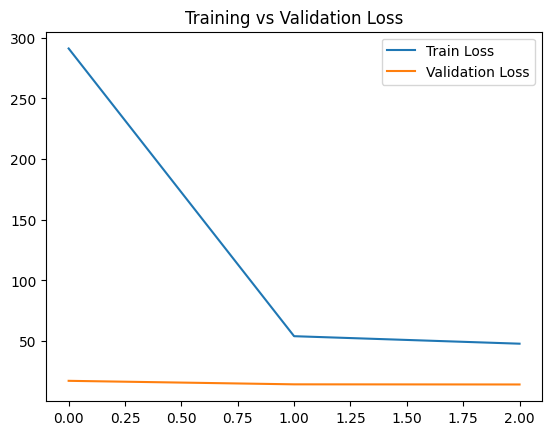

In [31]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


##STEP 6: We save the lastest trained model:
After training, we save the model’s `state_dict` back into `models/emergency_model.pt`.  
This ensures that the next time we run the notebook, we can resume from the latest trained version instead of retraining from zero.


In [32]:
torch.save(model.state_dict(), MODEL_PATH)
print("Model updated and saved.")


Model updated and saved.
